# Informe Teórico Práctico 2: Regresión Logística

SI3015 Fundamentos de Aprendizaje Automático, Universidad EAFIT, 2026

**Integrantes:** Julián Lara, Matías Martínez y Luis Alfonso Agudelo

**Dataset:** películas y series de IMDb (`movies dataset.csv`)


En este notebook resolvemos el punto 1.2 del taller. Convertimos el rating de IMDb en una clase binaria y tratamos de predecir si un título es **bien calificado** (rating mayor o igual a 7) o no.

**Concepto: regresión logística.** Aunque se llama regresión, es un modelo de clasificación. Calcula una combinación lineal de las variables, $z = b_0 + b_1 x_1 + \dots + b_n x_n$, y la pasa por la función sigmoide $\sigma(z) = 1 / (1 + e^{-z})$, que convierte cualquier número en una probabilidad entre 0 y 1. Si la probabilidad supera 0.5 se predice la clase positiva. Se entrena minimizando la entropía cruzada (log loss) en vez del error cuadrático. La elegimos porque es el modelo base para clasificación binaria, es rápida y sus coeficientes se pueden interpretar.

## 1. Carga del dataset

El archivo tiene 9999 filas y 9 columnas: título, año, género, rating, sinopsis, reparto, votos, duración y recaudo. Antes de modelar hay que revisar cómo vienen los datos porque casi todas las columnas están guardadas como texto.

In [1]:
# Librerias que usamos en todo el notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_curve, roc_auc_score)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
SEMILLA = 42  # semilla fija para que los resultados se puedan repetir

In [2]:
# El csv esta en la raiz del repositorio, un nivel arriba de esta carpeta
df_raw = pd.read_csv("../movies dataset.csv")
print("Filas y columnas:", df_raw.shape)
df_raw.head()

Filas y columnas: (9999, 9)


,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"\nAction, Horror, Thriller",6.1,\nA woman with a mysterious illness is forced ...,\n Director:\nPeter Thorwarth\n| \n Star...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"\nAnimation, Action, Adventure",5.0,\nThe war for Eternia begins again in what may...,"\n \n Stars:\nChris Wood, \nSara...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"\nDrama, Horror, Thriller",8.2,\nSheriff Deputy Rick Grimes wakes up from a c...,"\n \n Stars:\nAndrew Lincoln, \n...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"\nAnimation, Adventure, Comedy",9.2,\nAn animated series that follows the exploits...,"\n \n Stars:\nJustin Roiland, \n...","414,849",23.0,NaN
4,Army of Thieves,(2021),"\nAction, Crime, Horror",NaN,"\nA prequel, set before the events of Army of ...",\n Director:\nMatthias Schweighöfer\n| \n ...,NaN,NaN,NaN


In [3]:
# Tipo de dato y cantidad de faltantes de cada columna tal como viene el archivo
resumen = pd.DataFrame({
    "tipo": df_raw.dtypes.astype(str),
    "faltantes": df_raw.isna().sum(),
    "% faltantes": (df_raw.isna().mean() * 100).round(1),
})
resumen

,tipo,faltantes,% faltantes
MOVIES,str,0,0.0
YEAR,str,644,6.4
GENRE,str,80,0.8
RATING,float64,1820,18.2
ONE-LINE,str,0,0.0
STARS,str,0,0.0
VOTES,str,1820,18.2
RunTime,float64,2958,29.6
Gross,str,9539,95.4


In [4]:
# Asi se ve una fila por dentro: saltos de linea, espacios de relleno y varios datos en un mismo campo
for col in ["YEAR", "GENRE", "STARS", "VOTES", "Gross"]:
    print(f"{col:6}: {df_raw.loc[0, col]!r}")

YEAR  : '(2021)'
GENRE : '\nAction, Horror, Thriller            '
STARS : '\n    Director:\nPeter Thorwarth\n| \n    Stars:\nPeri Baumeister, \nCarl Anton Koch, \nAlexander Scheer, \nKais Setti\n'
VOTES : '21,062'
Gross : nan


## 2. Limpieza y transformación

Encontramos estos problemas en el archivo original:

1. Los campos de texto traen saltos de línea y espacios sobrantes.
2. `YEAR` mezcla el año con el tipo de producción, por ejemplo `(2021)`, `(2019– )` para una serie que sigue al aire, `(2005–2014)` para una serie terminada o `(2020 TV Special)`.
3. `VOTES` es texto con comas de miles y `Gross` es texto con el signo `$` y la letra `M`.
4. `STARS` junta director y actores en un solo campo.
5. Hay filas repetidas exactas.
6. Muchos títulos aparecen varias veces con distinto rating. Revisando, son episodios de una misma serie (por ejemplo `13 Reasons Why` aparece más de 30 veces).

La función de abajo resuelve todo eso y crea variables nuevas a partir del texto.

In [5]:
def limpiar_peliculas(df_raw):
    df = df_raw.copy()

    # Nombres cortos y en espanol para trabajar mas comodo
    df = df.rename(columns={
        "MOVIES": "titulo", "YEAR": "anio_texto", "GENRE": "genero", "RATING": "rating",
        "ONE-LINE": "sinopsis", "STARS": "reparto", "VOTES": "votos_texto",
        "RunTime": "duracion", "Gross": "recaudo_texto",
    })

    # Quitamos saltos de linea y espacios repetidos en los campos de texto
    for col in ["titulo", "anio_texto", "genero", "sinopsis", "reparto"]:
        df[col] = df[col].str.replace(r"\s+", " ", regex=True).str.strip()

    # Filas repetidas exactas
    n_antes = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print("Filas duplicadas eliminadas:", n_antes - len(df))

    # Del texto del anio sacamos: anio de inicio, si es serie, si sigue al aire y el tipo
    anio = df["anio_texto"].fillna("")
    df["anio_inicio"] = pd.to_numeric(anio.str.extract(r"(\d{4})")[0])
    df["es_serie"] = anio.str.contains("–").astype(int)
    df["en_emision"] = anio.str.contains(r"–\s*\)").astype(int)
    df["tipo"] = np.select(
        [anio.str.contains("–"), anio.str.contains("TV Special"), anio.str.contains("TV Movie"),
         anio.str.contains("Video"), anio.str.contains("TV Short")],
        ["Serie", "Especial TV", "Pelicula TV", "Video", "Corto TV"],
        default="Pelicula",
    )

    # Votos y recaudo pasan de texto a numero
    df["votos"] = pd.to_numeric(df["votos_texto"].str.replace(",", ""), errors="coerce")
    df["recaudo_millones"] = pd.to_numeric(
        df["recaudo_texto"].str.replace(r"[$M]", "", regex=True), errors="coerce")

    # Del reparto sacamos si hay director registrado y cuantos actores aparecen
    df["tiene_director"] = df["reparto"].str.contains("Director").astype(int)
    actores = df["reparto"].str.extract(r"Stars?:(.*)")[0].fillna("")
    df["n_actores"] = actores.apply(lambda s: len([a for a in s.split(",") if a.strip()]))

    # Cantidad de generos que tiene cada titulo
    df["n_generos"] = df["genero"].fillna("").apply(
        lambda s: len([g for g in s.split(",") if g.strip()]))

    # "Add a Plot" significa que IMDb no tiene sinopsis, lo marcamos aparte
    df["sin_sinopsis"] = (df["sinopsis"] == "Add a Plot").astype(int)
    df["largo_sinopsis"] = np.where(df["sin_sinopsis"] == 1, 0, df["sinopsis"].str.split().str.len())

    # Un titulo repetido corresponde a episodios de una misma serie
    conteo = df["titulo"].value_counts()
    df["es_episodio"] = (df["titulo"].map(conteo) > 1).astype(int)

    return df


df = limpiar_peliculas(df_raw)
df[["titulo", "anio_inicio", "tipo", "es_serie", "en_emision", "rating", "votos",
    "duracion", "tiene_director", "n_actores", "n_generos", "es_episodio"]].head(8)

Filas duplicadas eliminadas: 431


,titulo,anio_inicio,tipo,es_serie,en_emision,rating,votos,duracion,tiene_director,n_actores,n_generos,es_episodio
0,Blood Red Sky,2021.0,Pelicula,0,0,6.1,21062.0,121.0,1,4,3,0
1,Masters of the Universe: Revelation,2021.0,Serie,1,1,5.0,17870.0,25.0,0,4,3,1
2,The Walking Dead,2010.0,Serie,1,0,8.2,885805.0,44.0,0,4,3,0
3,Rick and Morty,2013.0,Serie,1,1,9.2,414849.0,23.0,0,4,3,1
4,Army of Thieves,2021.0,Pelicula,0,0,NaN,NaN,NaN,1,4,3,0
5,Outer Banks,2020.0,Serie,1,1,7.6,25858.0,50.0,0,4,3,1
6,The Last Letter from Your Lover,2021.0,Pelicula,0,0,6.8,5283.0,110.0,1,4,2,0
7,Dexter,2006.0,Serie,1,0,8.6,665387.0,53.0,0,4,3,1


In [6]:
# Faltantes despues de la limpieza en las columnas que nos interesan
cols = ["rating", "votos", "duracion", "anio_inicio", "genero", "recaudo_millones"]
(df[cols].isna().mean() * 100).round(1).to_frame("% faltantes")

,% faltantes
rating,14.6
votos,14.6
duracion,26.8
anio_inicio,6.6
genero,0.8
recaudo_millones,95.2


Con esos porcentajes tomamos varias decisiones:

1. **Recaudo:** le falta cerca del 95 % de los datos. Imputar tanto sería inventar la columna, así que no la usamos.
2. **Rating:** es la variable objetivo, y sin ella la fila no sirve para entrenar. Esas filas se eliminan. Casi siempre son títulos que todavía no se estrenan, porque tampoco tienen votos.
3. **Duración:** entre las filas que sí tienen rating le falta alrededor del 17 %. La llenamos con la mediana de su tipo, porque un episodio de serie dura mucho menos que una película y una mediana general mezclaría las dos cosas. También guardamos una columna que indica que el dato era faltante.
4. **Votos:** van desde 5 hasta casi dos millones y la distribución es muy asimétrica. Aplicamos `log(1 + votos)` para comprimir la escala.
5. **Género y tipo:** son categóricas, así que las pasamos a columnas 0/1 (one hot). Un título puede tener varios géneros a la vez.

In [7]:
def preparar_para_modelos(df):
    # Sin rating no hay objetivo, esas filas no sirven para entrenar
    d = df.dropna(subset=["rating"]).copy()

    # Duracion faltante: mediana de su mismo tipo y una bandera que indica que faltaba
    d["duracion_faltante"] = d["duracion"].isna().astype(int)
    d["duracion"] = d["duracion"].fillna(d.groupby("tipo")["duracion"].transform("median"))
    d["duracion"] = d["duracion"].fillna(d["duracion"].median())
    d["anio_inicio"] = d["anio_inicio"].fillna(d["anio_inicio"].median())

    # Logaritmo de los votos para reducir la asimetria
    d["log_votos"] = np.log1p(d["votos"])

    # Generos en formato one hot, una columna por genero
    generos = d["genero"].fillna("").str.get_dummies(sep=", ")
    generos.columns = ["gen_" + c.replace("-", "_") for c in generos.columns]

    # Tipo en one hot. Serie ya esta en es_serie y Pelicula queda como categoria base
    tipos = pd.get_dummies(d["tipo"], prefix="tipo", dtype=int)
    tipos.columns = [c.replace(" ", "_") for c in tipos.columns]
    tipos = tipos.drop(columns=["tipo_Serie", "tipo_Pelicula"])

    d = pd.concat([d, generos, tipos], axis=1).reset_index(drop=True)
    return d, list(generos.columns), list(tipos.columns)


d, cols_generos, cols_tipos = preparar_para_modelos(df)
print("Filas disponibles para modelar:", d.shape[0])
print("Columnas de genero:", len(cols_generos), "| columnas de tipo:", cols_tipos)

Filas disponibles para modelar: 8168
Columnas de genero: 27 | columnas de tipo: ['tipo_Corto_TV', 'tipo_Especial_TV', 'tipo_Pelicula_TV', 'tipo_Video']


### Variable objetivo

Creamos la columna `buena`, que vale 1 si el rating es mayor o igual a 7 y 0 si no. Escogimos 7 porque está muy cerca de la mediana del rating (7.1), así las dos clases quedan con un tamaño parecido. Además es un umbral que se usa mucho en IMDb para decir que algo vale la pena verlo.

Es importante que el rating **no** se use como variable de entrada, porque el objetivo sale directamente de él y el modelo haría trampa.

buena
buena (>= 7)      4472
no buena (< 7)    3696
Name: count, dtype: int64
buena
1    54.8
0    45.2
Name: proportion, dtype: float64


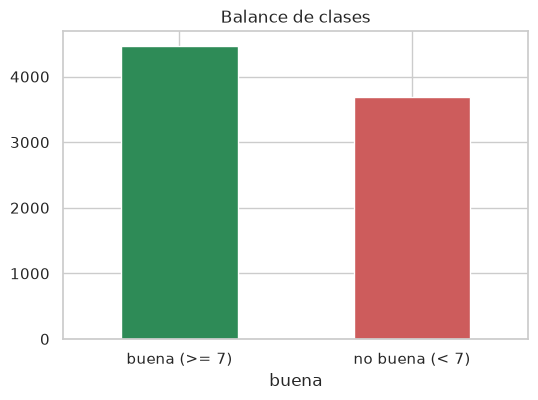

In [8]:
# Variable objetivo binaria
d["buena"] = (d["rating"] >= 7).astype(int)

conteo = d["buena"].value_counts().rename({1: "buena (>= 7)", 0: "no buena (< 7)"})
print(conteo)
print((d["buena"].value_counts(normalize=True) * 100).round(1))

conteo.plot(kind="bar", color=["seagreen", "indianred"], rot=0, figsize=(6, 4), title="Balance de clases")
plt.show()

## 3. Análisis exploratorio

Para clasificación nos interesa ver qué variables separan las dos clases. Un boxplot por clase muestra si la distribución de una variable cambia entre títulos buenos y no buenos. Para las variables binarias miramos qué porcentaje de títulos buenos hay cuando la variable vale 0 y cuando vale 1.

In [9]:
def resumen_iqr(serie):
    # Rango intercuartilico, limites de outliers e IQR ratio como se vio en clase
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return pd.Series({
        "Q1": q1, "Q3": q3, "IQR": iqr, "lim_inf": lim_inf, "lim_sup": lim_sup,
        "outliers": int(((serie < lim_inf) | (serie > lim_sup)).sum()),
        "IQR_ratio": iqr / (serie.max() - serie.min()),
    })


num = ["rating", "duracion", "votos", "log_votos", "anio_inicio", "n_actores", "n_generos", "largo_sinopsis"]
d[num].apply(resumen_iqr).T.round(3)

,Q1,Q3,IQR,lim_inf,lim_sup,outliers,IQR_ratio
rating,6.200,7.800,1.600,3.800,10.200,165.0,0.182
duracion,38.000,94.000,56.000,-46.000,178.000,116.0,0.066
votos,167.000,3780.750,3613.750,-5253.625,9201.375,1298.0,0.002
log_votos,5.124,8.238,3.114,0.453,12.909,43.0,0.248
anio_inicio,2015.000,2020.000,5.000,2007.500,2027.500,681.0,0.056
n_actores,4.000,4.000,0.000,4.000,4.000,952.0,0.000
n_generos,1.000,3.000,2.000,-2.000,6.000,0.0,0.667
largo_sinopsis,20.000,32.000,12.000,2.000,50.000,377.0,0.167


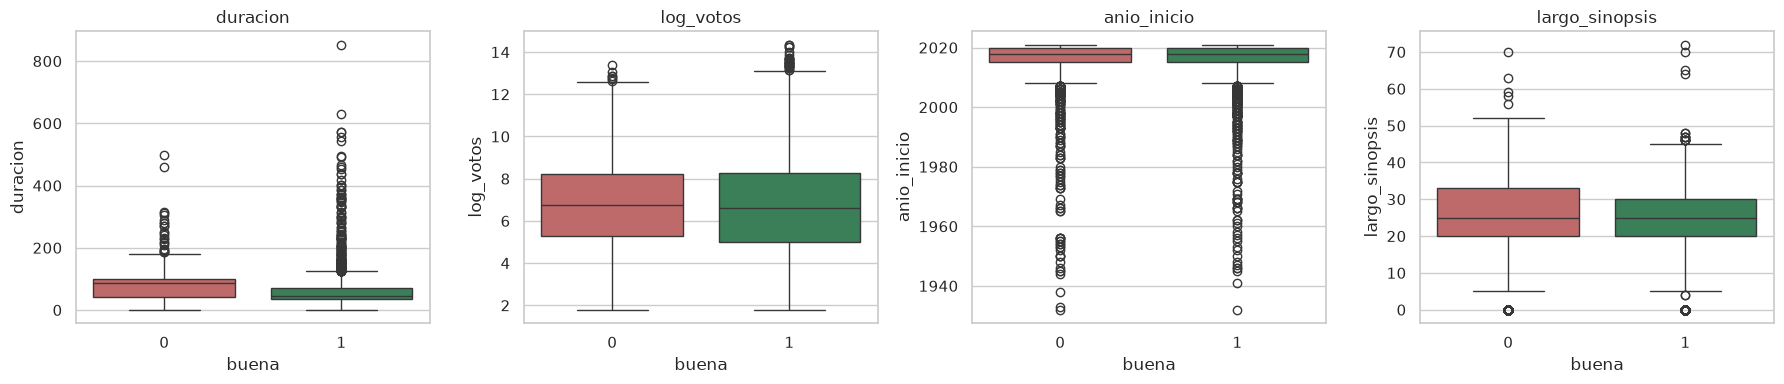

In [10]:
# Distribucion de las variables numericas separadas por clase
fig, ejes = plt.subplots(1, 4, figsize=(18, 4))
for eje, col in zip(ejes, ["duracion", "log_votos", "anio_inicio", "largo_sinopsis"]):
    sns.boxplot(data=d, x="buena", y=col, ax=eje, hue="buena", palette=["indianred", "seagreen"], legend=False)
    eje.set_title(col)
plt.tight_layout()
plt.show()

In [11]:
# Porcentaje de titulos buenos segun cada variable binaria
binarias = ["es_serie", "es_episodio", "en_emision", "tiene_director", "sin_sinopsis", "duracion_faltante"]
tabla_bin = pd.DataFrame({
    col: d.groupby(col)["buena"].mean().mul(100).round(1) for col in binarias
}).T
tabla_bin.columns = ["% buenas si vale 0", "% buenas si vale 1"]
tabla_bin

,% buenas si vale 0,% buenas si vale 1
es_serie,39.2,72.7
es_episodio,41.6,77.2
en_emision,49.4,67.2
tiene_director,65.0,49.8
sin_sinopsis,54.7,54.9
duracion_faltante,52.5,65.8


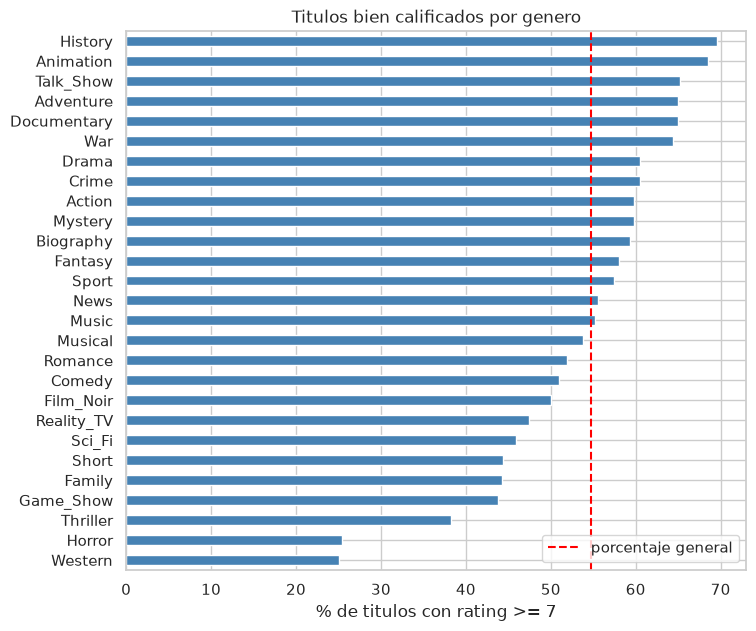

In [12]:
# Porcentaje de titulos buenos por genero
pct_genero = pd.Series({g.replace("gen_", ""): d.loc[d[g] == 1, "buena"].mean() * 100 for g in cols_generos}).sort_values()
plt.figure(figsize=(8, 7))
pct_genero.plot(kind="barh", color="steelblue")
plt.axvline(d["buena"].mean() * 100, color="red", ls="--", label="porcentaje general")
plt.xlabel("% de titulos con rating >= 7")
plt.title("Titulos bien calificados por genero")
plt.legend()
plt.show()

Lo que sacamos del análisis exploratorio:

1. Las clases están razonablemente balanceadas: 54.8 % buenas y 45.2 % no buenas. No hace falta balancear, pero hay que tener presente que un modelo que diga siempre "buena" ya acierta más o menos el 55 %.
2. La duración separa bien las clases. La mediana de los títulos buenos es de 44 minutos contra 86 de los no buenos.
3. `log_votos`, `anio_inicio` y `largo_sinopsis` casi no cambian entre clases (las medianas son prácticamente iguales).
4. Las variables binarias de estructura son las más fuertes. Entre las series el 72.7 % son buenas, contra 39.2 % en lo que no es serie. En los episodios la cifra sube a 77.2 %. En cambio, los títulos que tienen director registrado (casi siempre películas) son buenos solo el 49.8 % de las veces.
5. Por género, western, terror y thriller tienen muy pocos títulos buenos (entre 25 % y 38 %), mientras que documental, animación e historia llegan al 65 % o más.

### División entrenamiento y prueba

**Concepto.** Separar los datos en entrenamiento y prueba sirve para medir el modelo con datos que nunca vio. Si se evalúa con los mismos datos del entrenamiento, las métricas salen infladas.

Aquí hay un detalle propio de este dataset: los episodios de una misma serie tienen el mismo título, una duración parecida y votos parecidos. Con una división aleatoria normal, unos episodios caen en entrenamiento y otros en prueba, y el modelo termina reconociendo la serie en vez de aprender algo general. Por eso usamos `GroupShuffleSplit` agrupando por título: todos los episodios de una serie quedan del mismo lado. Dejamos el 80 % para entrenar y el 20 % para probar.

In [13]:
# Division 80/20 agrupando por titulo para que una serie no quede repartida en ambos conjuntos
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEMILLA)
idx_train, idx_test = next(gss.split(d, groups=d["titulo"]))
train, test = d.iloc[idx_train].copy(), d.iloc[idx_test].copy()

print("Entrenamiento:", train.shape[0], "filas")
print("Prueba:", test.shape[0], "filas")
print("Titulos compartidos entre ambos:", len(set(train["titulo"]) & set(test["titulo"])))

Entrenamiento: 6447 filas
Prueba: 1721 filas
Titulos compartidos entre ambos: 0


### Escalado y métricas

**Escalado.** `LogisticRegression` de scikit learn aplica regularización por defecto, y la regularización castiga el tamaño de los coeficientes. Si una variable está en minutos (hasta 800) y otra en 0/1, el castigo no queda parejo. Por eso usamos `StandardScaler` (media 0 y desviación 1) dentro de un `Pipeline`. El pipeline garantiza que la media y la desviación se calculen solo con el entrenamiento y después se apliquen igual a prueba.

**Métricas.** Tomando como positiva la clase `buena`:

1. **Matriz de confusión:** tabla con verdaderos negativos, falsos positivos, falsos negativos y verdaderos positivos.
2. **Accuracy:** porcentaje total de aciertos. Sirve cuando las clases están balanceadas, como en este caso.
3. **Precision:** de los títulos que el modelo dijo que eran buenos, cuántos lo eran de verdad. Es $VP / (VP + FP)$.
4. **Recall:** de los títulos que sí eran buenos, cuántos encontró el modelo. Es $VP / (VP + FN)$.
5. **F1 score:** media armónica entre precision y recall. Solo sale alta si las dos son altas.

In [14]:
def evaluar_clasificador(columnas, nombre, mostrar=True):
    # Pipeline: primero escala y despues ajusta la regresion logistica
    modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    modelo.fit(train[columnas], train["buena"])
    pred = modelo.predict(test[columnas])
    pred_train = modelo.predict(train[columnas])
    metricas = {
        "modelo": nombre,
        "n_variables": len(columnas),
        "accuracy_train": accuracy_score(train["buena"], pred_train),
        "accuracy": accuracy_score(test["buena"], pred),
        "precision": precision_score(test["buena"], pred),
        "recall": recall_score(test["buena"], pred),
        "f1": f1_score(test["buena"], pred),
    }
    if mostrar:
        fig, eje = plt.subplots(figsize=(4.5, 4))
        ConfusionMatrixDisplay(confusion_matrix(test["buena"], pred), display_labels=["no buena", "buena"]).plot(
            ax=eje, cmap="Blues", colorbar=False)
        eje.set_title(nombre)
        plt.show()
        print(classification_report(test["buena"], pred, target_names=["no buena", "buena"], digits=3))
    return modelo, pred, metricas


# Referencia: predecir siempre la clase mayoritaria del entrenamiento
mayoritaria = train["buena"].mode()[0]
print(f"Accuracy prediciendo siempre la clase mayoritaria: {(test['buena'] == mayoritaria).mean():.3f}")

Accuracy prediciendo siempre la clase mayoritaria: 0.566


## 4. Caso 1: regresión logística con una variable

**Enunciado.** Aplicar regresión logística seleccionando una única columna característica y una variable objetivo, obtener métricas de desempeño (matriz de confusión, accuracy, f1 score, precision, recall), redactar los procesos relevantes y sacar conclusiones.

**Variable objetivo:** `buena` (rating mayor o igual a 7).

**Variable característica:** `duracion`. Es la variable continua que mejor separa las clases en los boxplots: los títulos buenos tienden a durar menos, porque ahí entran muchos episodios de series.

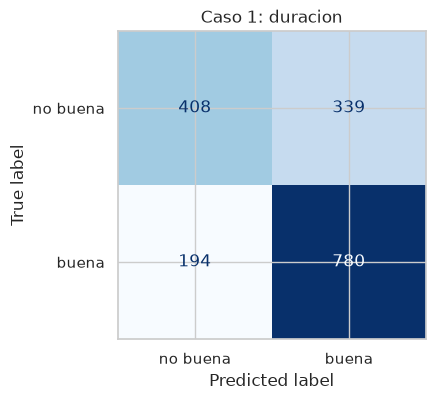

              precision    recall  f1-score   support

    no buena      0.678     0.546     0.605       747
       buena      0.697     0.801     0.745       974

    accuracy                          0.690      1721
   macro avg      0.687     0.674     0.675      1721
weighted avg      0.689     0.690     0.684      1721



,modelo,n_variables,accuracy_train,accuracy,precision,recall,f1
0,Caso 1: duracion,1,0.6671,0.6903,0.6971,0.8008,0.7453


In [15]:
modelo_1, pred_1, met_1 = evaluar_clasificador(["duracion"], "Caso 1: duracion")
pd.DataFrame([met_1]).round(4)

Coeficiente (variable escalada): -0.4612
Coeficiente por minuto: -0.01037
El modelo predice 'buena' cuando la duracion es menor a unos 83 minutos


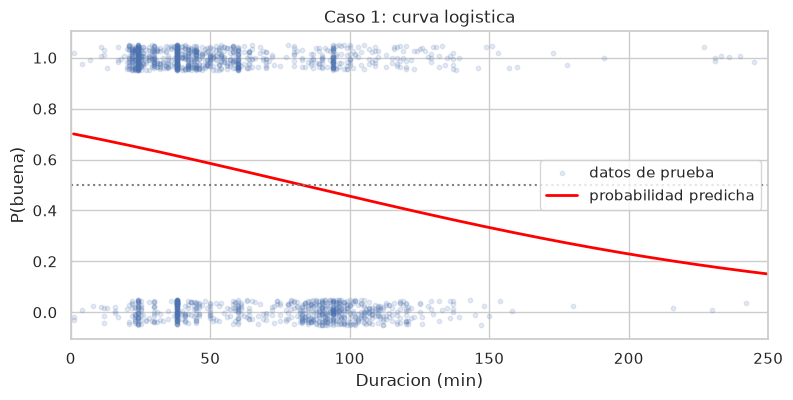

In [16]:
# Curva sigmoide aprendida: probabilidad de ser buena segun la duracion
x = pd.DataFrame({"duracion": np.linspace(1, 250, 300)})
prob = modelo_1.predict_proba(x)[:, 1]
coef = modelo_1.named_steps["logisticregression"].coef_[0][0]
escala = modelo_1.named_steps["standardscaler"].scale_[0]
print(f"Coeficiente (variable escalada): {coef:.4f}")
print(f"Coeficiente por minuto: {coef / escala:.5f}")

# Duracion donde la probabilidad cruza 0.5
corte = x["duracion"][np.argmin(np.abs(prob - 0.5))]
print(f"El modelo predice 'buena' cuando la duracion es menor a unos {corte:.0f} minutos")

plt.figure(figsize=(9, 4))
plt.scatter(test["duracion"], test["buena"] + np.random.default_rng(SEMILLA).uniform(-0.05, 0.05, len(test)),
            alpha=0.15, s=10, label="datos de prueba")
plt.plot(x["duracion"], prob, color="red", lw=2, label="probabilidad predicha")
plt.axhline(0.5, color="gray", ls=":")
plt.xlim(0, 250)
plt.xlabel("Duracion (min)")
plt.ylabel("P(buena)")
plt.title("Caso 1: curva logistica")
plt.legend()
plt.show()

### Conclusiones del caso 1

Con solo la duración el modelo llega a un accuracy de 0.690, contra 0.566 de predecir siempre la clase mayoritaria. El coeficiente es negativo: a mayor duración, menor probabilidad de que el título sea bueno. La curva sigmoide cruza 0.5 alrededor de los 83 minutos, así que en la práctica el modelo aprendió una regla simple: "si dura menos de hora y media, es buena".

La matriz de confusión muestra que esa regla funciona mucho mejor para una clase que para la otra. De 974 títulos buenos encuentra 780 (recall de 0.80), pero de los 747 no buenos solo reconoce 408 y los otros 339 los marca como buenos. El F1 de la clase buena es 0.745, pero el de la clase no buena baja a 0.605.

El accuracy de entrenamiento (0.667) y el de prueba (0.690) son parecidos, así que no hay sobreajuste. Con una sola variable el modelo es muy simple y lo que tiene es falta de información (subajuste).

## 5. Caso 2: regresión logística con varias variables

**Enunciado.** Aplicar regresión logística seleccionando dos columnas características y una variable objetivo, obtener las mismas métricas y agregar las columnas que sean necesarias para mejorarlas.

Empezamos con `duracion` y `log_votos` y después agregamos los mismos grupos que en regresión lineal:

1. **Estructura del título:** si es serie, si es episodio y si sigue al aire.
2. **Datos adicionales:** año de inicio, si tiene director, número de actores, número de géneros, largo de la sinopsis, si le falta sinopsis y si le faltaba la duración.
3. **Géneros y tipo de producción** en one hot.

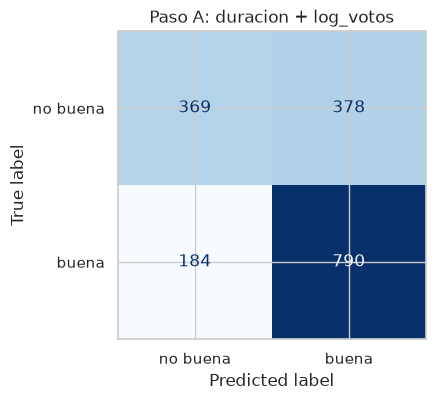

              precision    recall  f1-score   support

    no buena      0.667     0.494     0.568       747
       buena      0.676     0.811     0.738       974

    accuracy                          0.673      1721
   macro avg      0.672     0.653     0.653      1721
weighted avg      0.672     0.673     0.664      1721



In [17]:
# Grupos de variables que vamos agregando por pasos
vars_estructura = ["es_serie", "es_episodio", "en_emision"]
vars_extra = ["anio_inicio", "tiene_director", "n_actores", "n_generos",
              "largo_sinopsis", "sin_sinopsis", "duracion_faltante"]
todas = ["duracion", "log_votos"] + vars_estructura + vars_extra + cols_generos + cols_tipos

# Paso A: exactamente dos variables, con su matriz de confusion
modelo_a, pred_a, met_a = evaluar_clasificador(["duracion", "log_votos"], "Paso A: duracion + log_votos")

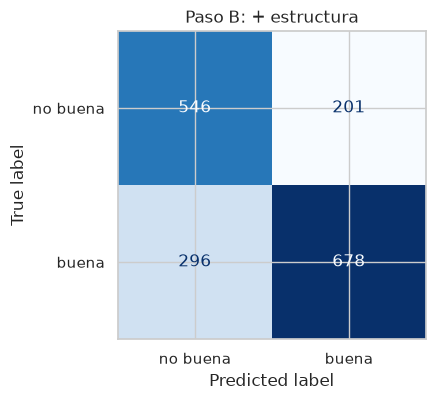

              precision    recall  f1-score   support

    no buena      0.648     0.731     0.687       747
       buena      0.771     0.696     0.732       974

    accuracy                          0.711      1721
   macro avg      0.710     0.714     0.710      1721
weighted avg      0.718     0.711     0.712      1721



In [18]:
# Paso B: se agrega la estructura del titulo
cols_b = ["duracion", "log_votos"] + vars_estructura
modelo_b, pred_b, met_b = evaluar_clasificador(cols_b, "Paso B: + estructura")

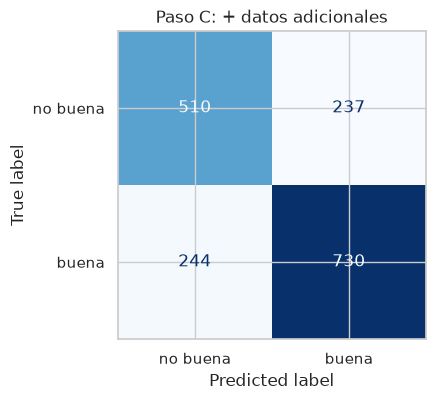

              precision    recall  f1-score   support

    no buena      0.676     0.683     0.680       747
       buena      0.755     0.749     0.752       974

    accuracy                          0.721      1721
   macro avg      0.716     0.716     0.716      1721
weighted avg      0.721     0.721     0.721      1721



In [19]:
# Paso C: se agregan los datos adicionales
cols_c = cols_b + vars_extra
modelo_c, pred_c, met_c = evaluar_clasificador(cols_c, "Paso C: + datos adicionales")

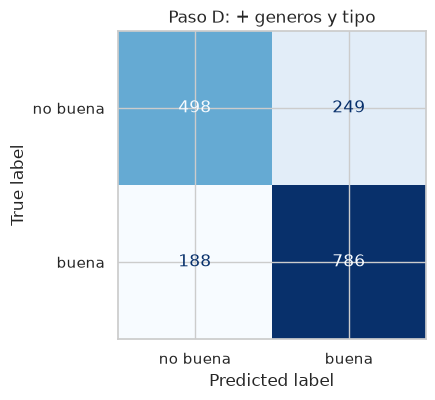

              precision    recall  f1-score   support

    no buena      0.726     0.667     0.695       747
       buena      0.759     0.807     0.782       974

    accuracy                          0.746      1721
   macro avg      0.743     0.737     0.739      1721
weighted avg      0.745     0.746     0.745      1721



,n_variables,accuracy_train,accuracy,precision,recall,f1
modelo,,,,,,
Caso 1: duracion,1,0.6671,0.6903,0.6971,0.8008,0.7453
Paso A: duracion + log_votos,2,0.6532,0.6734,0.6764,0.8111,0.7376
Paso B: + estructura,5,0.7058,0.7112,0.7713,0.6961,0.7318
Paso C: + datos adicionales,12,0.7202,0.7205,0.7549,0.7495,0.7522
Paso D: + generos y tipo,43,0.7568,0.7461,0.7594,0.8070,0.7825


In [20]:
# Paso D: todas las variables
modelo_d, pred_d, met_d = evaluar_clasificador(todas, "Paso D: + generos y tipo")
resultados = [met_1, met_a, met_b, met_c, met_d]

tabla = pd.DataFrame(resultados).set_index("modelo").round(4)
tabla

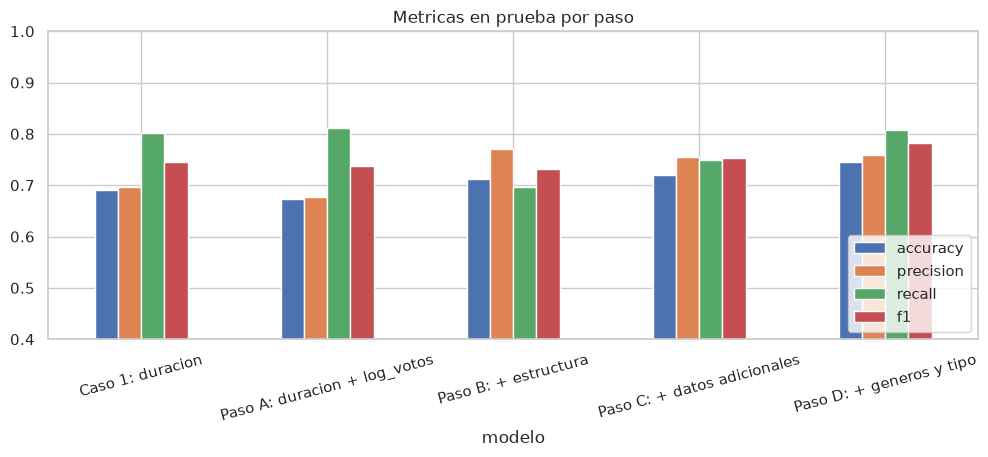

In [21]:
# Comparacion grafica de las metricas por paso
tabla[["accuracy", "precision", "recall", "f1"]].plot(kind="bar", figsize=(12, 4), rot=15, ylim=(0.4, 1))
plt.title("Metricas en prueba por paso")
plt.legend(loc="lower right")
plt.show()

### Curva ROC

**Concepto: curva ROC y AUC.** Todas las métricas anteriores usan el umbral de 0.5 para decidir la clase. La curva ROC muestra qué pasa con todos los umbrales posibles: en el eje X la tasa de falsos positivos y en el eje Y la tasa de verdaderos positivos (el recall). El **AUC** es el área bajo esa curva. Vale 1 para un modelo perfecto y 0.5 para uno que adivina al azar (la diagonal). Sirve para comparar modelos sin depender del umbral, y se puede leer como la probabilidad de que el modelo le dé más puntaje a un título bueno que a uno no bueno escogidos al azar.

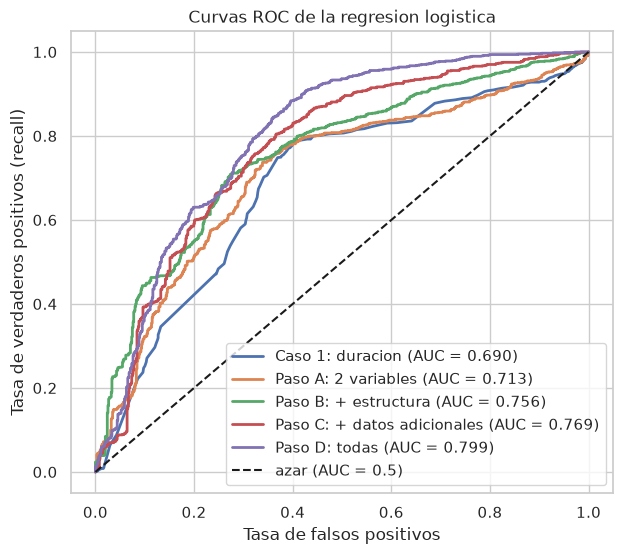

In [22]:
# Curva ROC de cada paso usando la probabilidad predicha de la clase buena
modelos_roc = {
    "Caso 1: duracion": (modelo_1, ["duracion"]),
    "Paso A: 2 variables": (modelo_a, ["duracion", "log_votos"]),
    "Paso B: + estructura": (modelo_b, cols_b),
    "Paso C: + datos adicionales": (modelo_c, cols_c),
    "Paso D: todas": (modelo_d, todas),
}
plt.figure(figsize=(7, 6))
auc = {}
for nombre, (modelo, columnas) in modelos_roc.items():
    prob = modelo.predict_proba(test[columnas])[:, 1]
    fpr, tpr, _ = roc_curve(test["buena"], prob)
    auc[nombre] = roc_auc_score(test["buena"], prob)
    plt.plot(fpr, tpr, lw=2, label=f"{nombre} (AUC = {auc[nombre]:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="azar (AUC = 0.5)")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curvas ROC de la regresion logistica")
plt.legend(loc="lower right")
plt.show()

El AUC sube en cada paso: 0.690 con la duración, 0.713 con dos variables, 0.756 con la estructura, 0.769 con los datos adicionales y **0.799** con todas las variables. Todas las curvas quedan por encima de la diagonal, así que todos los modelos son mejores que adivinar.

Hay un detalle interesante con el paso A. Con el umbral de 0.5 el accuracy había bajado respecto al caso 1, pero el AUC sube de 0.690 a 0.713. Los votos sí ayudan a ordenar mejor los títulos de más a menos probable de ser buenos. Lo que pasa es que esa mejora no se nota justo en el umbral de 0.5. Por eso conviene mirar el AUC además de las métricas con un solo umbral.

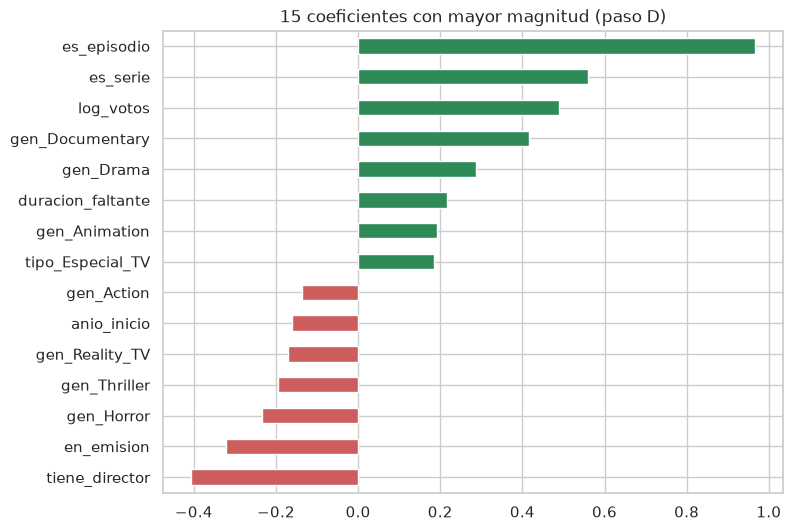

In [23]:
# Coeficientes del modelo final (sobre variables escaladas, por eso se pueden comparar entre si)
coef = pd.Series(modelo_d.named_steps["logisticregression"].coef_[0], index=todas)
top = coef.reindex(coef.abs().sort_values(ascending=False).index).head(15).sort_values()
top.plot(kind="barh", figsize=(8, 6), color=np.where(top > 0, "seagreen", "indianred"))
plt.title("15 coeficientes con mayor magnitud (paso D)")
plt.show()

### Conclusiones del caso 2

Con las dos variables del paso A el modelo **empeora** un poco respecto al caso 1: el accuracy baja de 0.690 a 0.673 y el F1 de 0.745 a 0.738. Revisando por qué, la relación entre votos y rating no es monótona. Los títulos con muy pocos votos y los que tienen muchísimos votos tienen más proporción de buenos que los del medio, y eso una regresión logística no lo puede capturar porque solo aprende efectos que suben o bajan en una sola dirección. Esto muestra que agregar una variable no siempre ayuda.

Al agregar la estructura del título (paso B) el accuracy sube a 0.711 y la precision pasa de 0.68 a 0.77. El modelo deja de marcar como buenos tantos títulos que no lo son. Los datos adicionales (paso C) suben el accuracy a 0.721, y los géneros y el tipo (paso D) lo llevan a **0.746**, con F1 de 0.783, precision de 0.759 y recall de 0.807.

En la matriz de confusión del paso D los falsos positivos bajan de 339 (caso 1) a 249, mientras los verdaderos positivos se mantienen (786 contra 780). La mejora viene sobre todo de reconocer mejor los títulos no buenos.

Los coeficientes más grandes del modelo final son `es_episodio`, `es_serie` y `log_votos` (positivos), documental y drama (positivos), y `tiene_director`, `en_emision`, terror y thriller (negativos). Llama la atención que `log_votos` sí pesa cuando va acompañado de las demás variables. Por sí sola no separaba las clases, pero comparando títulos del mismo tipo y género, más votos sí se asocian a mejor nota.

El accuracy de entrenamiento (0.757) y el de prueba (0.746) siguen muy cerca, así que tampoco hay sobreajuste con 43 variables.

## 6. Conclusiones generales

1. La regresión logística predice si un título es bien calificado con un accuracy de 0.746 y un F1 de 0.783 usando todas las variables, bastante por encima del 0.566 de adivinar siempre la clase mayoritaria.
2. Como en regresión lineal, lo que más ayuda es saber si el título es serie o episodio, seguido del género. Estas variables no venían en el archivo: se sacaron limpiando el texto de las columnas de año y género.
3. Agregar variables sin revisar la relación que tienen con el objetivo puede empeorar el modelo, como pasó con los votos en el paso A. La regresión logística asume que cada variable empuja la probabilidad en una sola dirección.
4. Mirar solo el accuracy esconde información. La matriz de confusión mostró que con pocas variables el modelo casi siempre dice "buena" y falla mucho con la clase negativa. Por eso conviene revisar precision, recall y F1 de cada clase.
5. En el notebook de Random Forest repetimos estos mismos casos para comparar un modelo lineal con uno basado en árboles, que sí puede aprender relaciones no monótonas como la de los votos.